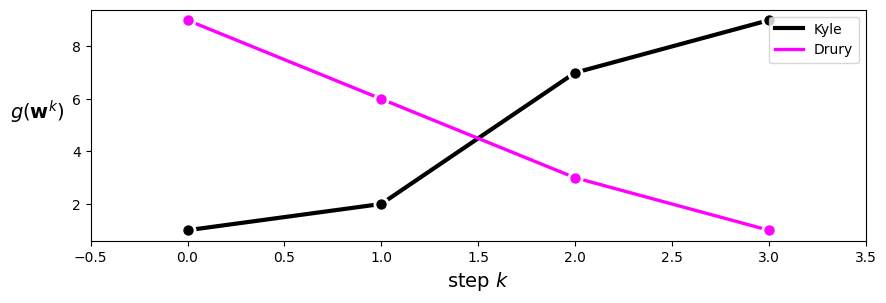

In [3]:
## Question 1

import sys
sys.path.append("../MLRPlotting/")
from MLRPlotting import static_plotter
import matplotlib.pyplot as plt
# import custom plotting tools
static_plotter = static_plotter.Visualizer();
cost_1 = [1,2,7,9]
cost_2 = [9,6,3,1]
# plot the cost function history for two runs
static_plotter.plot_cost_histories([cost_1,cost_2], start=0,points=True, labels=["Kyle", "Drury"])

In [29]:
##  Question 2
import numpy as np

num_samples = 3
D = 2
directions = np.random.randn(num_samples, D)
print(directions)

[[-0.98800028 -1.56543065]
 [-1.34882497  1.42289121]
 [-0.45740935 -0.56696724]]


In [30]:
result1 = np.sum(directions*directions)
result2 = np.sum(directions*directions,axis=0)
result3 = np.sum(directions*directions,axis=1)
print("result1:", result1)
print("result2:", result2)
print("result3:", result3)

result1: 7.801341022262744
result2: [3.00469667 4.79664436]
result3: [3.42671766 3.8439482  0.53067516]


In [32]:
psum = np.sum(directions * directions, axis=1)  # the squared norm of each vector
norms = np.sqrt(psum)  # the norm of each vector
norms.shape = (num_samples, 1)  # reshape to make it a column vector
directions = directions / norms  # divide each row by its norm
print("Normalized directions:\n", directions)

# compute the new norms to verify they are all 1
new_psum = np.sum(directions * directions, axis=1)
new_norms = np.sqrt(new_psum)
print("New norms (should be all ones):\n", new_norms)

Normalized directions:
 [[-0.53372544 -0.84565782]
 [-0.68796578  0.72574313]
 [-0.62790025 -0.77829382]]
New norms (should be all ones):
 [1. 1. 1.]


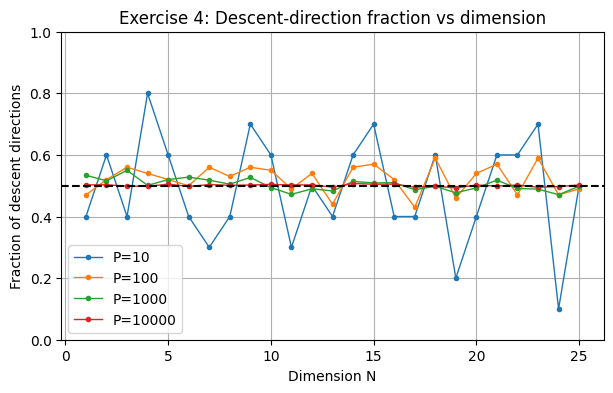

In [7]:
# Question 4

def g(w):  # g(w)
    return np.dot(w, w) + 2

def grad_g(w):  # gradient of g(w)
    return 2*w

def descent_fraction(N, P, seed=None):
    rng = np.random.default_rng(seed)  # produce random numbers

    w0 = np.zeros(N)   # initial point
    w0[0] = 1.0        # explicitly set the first component to 1
    grad = grad_g(w0)  # gradient at w0

    directions = rng.standard_normal((P, N))  # create P random directions in N dimensions
    directions /= np.linalg.norm(directions, axis=1)[:, None]  # normalize to unit length

    descent = np.array([np.dot(grad, d) < 0 for d in directions])  # dot grad with each direction to check for descent

    return np.mean(descent)  # the fraction of descent directions is an average because descent is boolean (True=1, False=0)

Ns = np.arange(1, 26)         # N = 1..25
Ps = [10, 100, 1000, 10000]   # different numbers of random directions

plt.figure(figsize=(7,4))

for P in Ps:
    fracs = [descent_fraction(N, P, seed=0) for N in Ns]
    plt.plot(Ns, fracs, marker='o', linewidth=1, markersize=3, label=f"P={P}")

plt.axhline(0.5, linestyle='--', color='black')  # expected value
plt.ylim(0, 1)
plt.xlabel("Dimension N")
plt.ylabel("Fraction of descent directions")
plt.title("Exercise 4: Descent-direction fraction vs dimension")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
def coordinate_search(g, alpha_choice, max_its, w0):
    w = np.array(w0, dtype=float)  # ensure w is a float array
    N = w.size  # dimension of w

    directions = np.vstack([np.eye(N), -np.eye(N)])  # np.eye(N) creates N unit vectors; stack with their negatives to get 2N directions

    w_history = [w.copy()]  # create containers to store weight and cost histories
    cost_history = [g(w)]

    for k in range(1, max_its + 1):
        alpha = (1.0 / k) if (alpha_choice == "diminishing") else float(alpha_choice)

        # candidate points: w + alpha*d for all 2N directions
        candidates = w + alpha * directions           # evaluate all candidates, shape (2N, N)
        costs = np.array([g(c) for c in candidates])  # evaluate costs for all candidates, shape (2N,)
        best_idx = np.argmin(costs)                   # index of the best candidate (the least cost)

        w = candidates[best_idx]    # update w to best candidate
        w_history.append(w.copy())  # record weight
        cost_history.append(g(w))   # record cost

    return np.array(w_history), np.array(cost_history)

In [8]:
def coordinate_descent(g, max_its, w0, seed=0):
    rng = np.random.default_rng(seed)  # random number generator

    w = np.array(w0, dtype=float)
    N = w.size
    directions = np.vstack([np.eye(N), -np.eye(N)])  # (2N, N)

    w_hist = [w.copy()]
    c_hist = [g(w)]

    for k in range(1, max_its + 1):
        alpha = 1.0 / k  # diminishing step length

        perm = rng.permutation(2 * N)  # random order of the 2N directions
        steps_taken = 0

        for idx in perm:           # loop over directions in random order
            d = directions[idx]    # current direction
            w_try = w + alpha * d  # candidate point

            if g(w_try) < g(w):          # first descent found
                w = w_try                # take the step
                w_hist.append(w.copy())  # record new w
                c_hist.append(g(w))      # record new cost

                steps_taken += 1      # increment accepted steps
                if steps_taken >= N:  # at most N accepted steps per permutation
                    break

        # if none improve, w stays the same for this permutation

    return np.array(w_hist), np.array(c_hist)

Final cost (coord search):  2.000000669996788  final w: [-0.0008015  -0.00016613]
Final cost (coord descent): 2.0003123851359925  final w: [0.0124977 0.0124977]


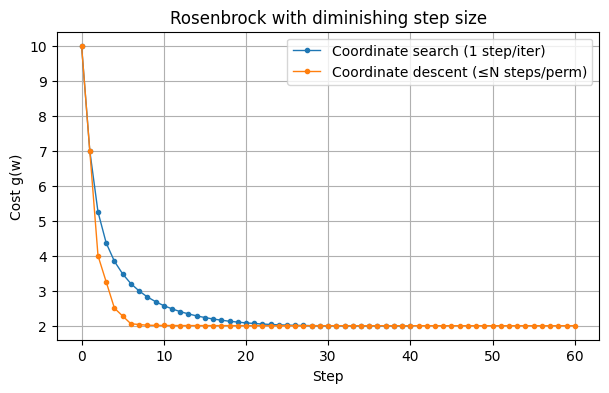

In [13]:
w0 = np.array([-2.0, -2.0])
P = 40

w_cs, c_cs = coordinate_search(g, "diminishing", P, w0)
w_cd, c_cd = coordinate_descent(g, P, w0, seed=0)

print("Final cost (coord search): ", c_cs[-1], " final w:", w_cs[-1])
print("Final cost (coord descent):", c_cd[-1], " final w:", w_cd[-1])

plt.figure(figsize=(7,4))
plt.plot(c_cs, marker='o', markersize=3, linewidth=1, label="Coordinate search (1 step/iter)")
plt.plot(c_cd, marker='o', markersize=3, linewidth=1, label="Coordinate descent (≤N steps/perm)")
#plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Cost g(w)")
plt.title("Rosenbrock with diminishing step size")
plt.grid(True)
plt.legend()
plt.show()